# Import Required Libraries

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
cd /content/drive/MyDrive/Machine learning 2024/Notebooks - ANN - DNN/11.Auto encoder/Denoising brain tumor project

/content/drive/MyDrive/Machine learning 2024/Notebooks - ANN - DNN/11.Auto encoder/Denoising brain tumor project


In [3]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import os
import pandas as pd
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Conv2D, Conv2DTranspose, Input, MaxPooling2D, UpSampling2D
from tensorflow.keras.optimizers import Adam

# Load Data

In [4]:
root_dir = "dataset/"

In [5]:
image_paths = os.listdir(root_dir)
len(image_paths)

100

In [6]:
images = []

for image_path in image_paths:
    img = load_img(root_dir + image_path, target_size=(64, 64), color_mode="grayscale")
    img = img_to_array(img)
    img = img / 255.
    images.append(img)

In [7]:
images = np.array(images)

In [8]:
type(images)

numpy.ndarray

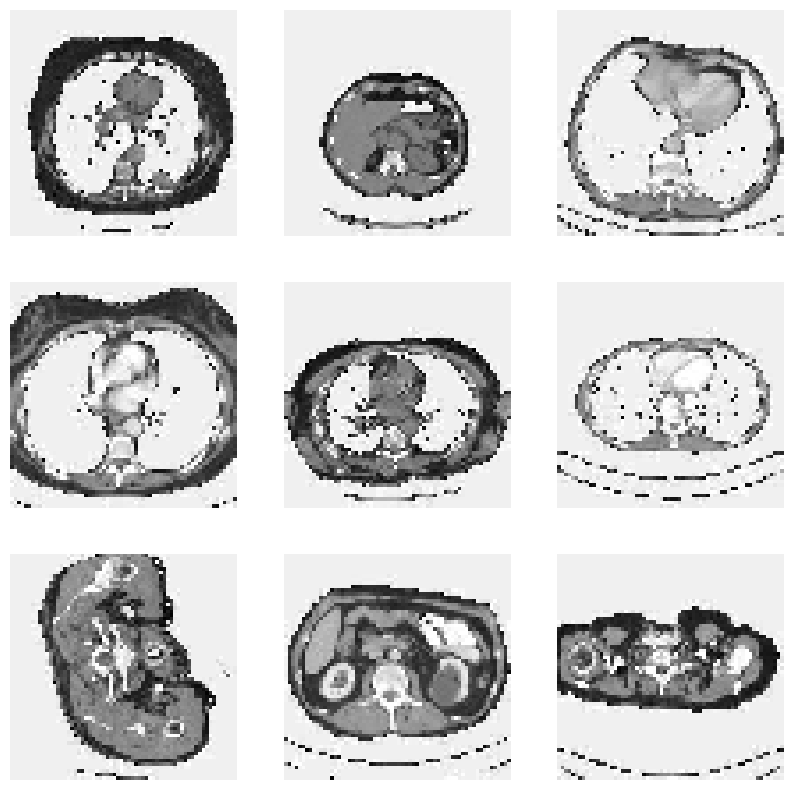

In [9]:
# plot some images

import matplotlib.pyplot as plt
plt.figure(figsize=(10, 10))
for i in range(9):
    plt.subplot(3, 3, i + 1)
    plt.imshow(images[i].reshape(64, 64), cmap='gray')
    plt.axis('off')
plt.show()


In [10]:
noise_factor = 0.2

noise_images = []

for image in images:
    noisy = image + noise_factor * np.random.randn(*image.shape) #64 *64
    noisy = np.clip(noisy, 0., 1.)
    noise_images.append(noisy)

np.clip(noisy, 0., 1.) limits (or "clips") the values of the noisy image array.
If any value in the noisy array is less than 0., it will be set to 0..
If any value in the noisy array is greater than 1., it will be set to 1..

In [11]:
noise_images = np.array(noise_images)

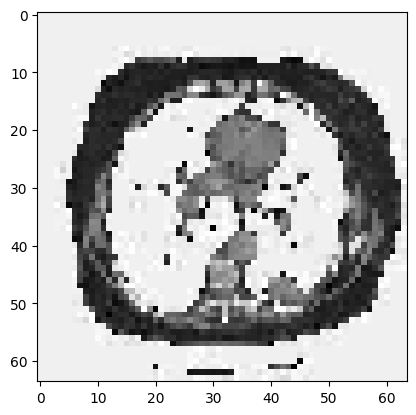

In [12]:
plt.imshow(images[0], cmap="gray")

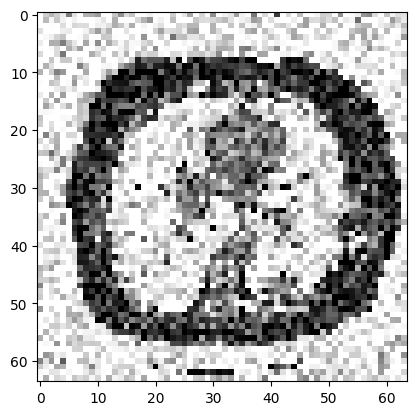

In [13]:
plt.imshow(noise_images[0], cmap="gray")

In [14]:
noise_train = noise_images[:80]
noise_test = noise_images[80:]

noise_train.shape, noise_test.shape

((80, 64, 64, 1), (20, 64, 64, 1))

In [15]:
normal_train = images[:80]
normal_test = images[80:]

normal_train.shape, normal_test.shape

((80, 64, 64, 1), (20, 64, 64, 1))

# Models

In [16]:
from keras.models import Sequential, Model
from keras.layers import Dense, Conv2D, MaxPooling2D,MaxPool2D ,UpSampling2D, Flatten, Input
from keras.optimizers import SGD, Adam, Adadelta, Adagrad
from keras import backend as K

In [ ]:
def autoencoder():

    input_img = Input(shape=(64,64,1), name='image_input')

    #enoder
    x = Conv2D(64, (3,3), activation='relu', padding='same', name='Conv1')(input_img)
    x = MaxPooling2D((2,2), padding='same', name='pool1')(x)
    x = Conv2D(64, (3,3), activation='relu', padding='same', name='Conv2')(x)
    x = MaxPooling2D((2,2), padding='same', name='pool2')(x)   #32

    #decoder
    x = Conv2D(64, (3,3), activation='relu', padding='same', name='Conv3')(x)
    x = UpSampling2D((2,2), name='upsample1')(x)
    x = Conv2D(64, (3,3), activation='relu', padding='same', name='Conv4')(x)
    x = UpSampling2D((2,2), name='upsample2')(x)
    x = Conv2D(1, (3,3), activation='sigmoid', padding='same', name='Conv5')(x)

    #model
    autoencoder = Model(inputs=input_img, outputs=x)
    autoencoder.compile(optimizer='adam', loss='binary_crossentropy')

    return autoencoder

In [ ]:
model= autoencoder()
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ image_input (InputLayer)             │ (None, 64, 64, 1)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ Conv1 (Conv2D)                       │ (None, 64, 64, 64)          │             640 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ pool1 (MaxPooling2D)                 │ (None, 32, 32, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ Conv2 (Conv2D)                       │ (None, 32, 32, 64)          │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ pool2 (MaxPooling2D)                 │ (None, 16, 16, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ Conv3 (Conv2D)                       │ (None, 16, 16, 64)          │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ upsample1 (UpSampling2D)             │ (None, 32, 32, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ Conv4 (Conv2D)                       │ (None, 32, 32, 64)          │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ upsample2 (UpSampling2D)             │ (None, 64, 64, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ Conv5 (Conv2D)                       │ (None, 64, 64, 1)           │             577 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 112,001 (437.50 KB)

 Trainable params: 112,001 (437.50 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.fit(noise_train,
                 normal_train,
                 validation_data=(noise_test, normal_test),
                 epochs=50,
                 batch_size=16)

Epoch 1/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 6s 262ms/step - loss: 0.6264 - val_loss: 0.5683
Epoch 2/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.5731 - val_loss: 0.5550
Epoch 3/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.5376 - val_loss: 0.5210
Epoch 4/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.4993 - val_loss: 0.4813
Epoch 5/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.4623 - val_loss: 0.4583
Epoch 6/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.4533 - val_loss: 0.4593
Epoch 7/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.4575 - val_loss: 0.4567
Epoch 8/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.4469 - val_loss: 0.4480
Epoch 9/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.4467 - val_loss: 0.4433
Epoch 10/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.4407 - val_loss: 0.4408
Epoch 11/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.4280 - val_loss: 0.4390
Epoch 12/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.4301 - val_loss: 0.4383


In [ ]:
predicted = model.predict(noise_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 657ms/step


In [ ]:
from sklearn.metrics import mean_squared_error
# Calculate Mean Squared Error (MSE)
actual_values_flat = normal_test.flatten()
predicted_values_flat = predicted.flatten()

mse = mean_squared_error(actual_values_flat, predicted_values_flat)

print("Mean Squared Error:", mse)

Mean Squared Error: 0.022770695


In [ ]:
evaluation = model.evaluate(noise_test, normal_test)
evaluation

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 248ms/step - loss: 0.4133


0.4132970869541168

In [ ]:
def plot_predictions(test, preds):
    plt.figure(figsize=(12, 6))

    # Noise test
    for i in range(16):
        plt.subplot(4, 8, i + 1)
        plt.imshow(test[i], cmap='gray')
        plt.axis('off')
        plt.title('Noised')

    # Predicted
    for i in range(16):
        plt.subplot(4, 8, i + 17)
        plt.imshow(preds[i], cmap='gray')
        plt.axis('off')
        plt.title('Predicted')

    plt.show()

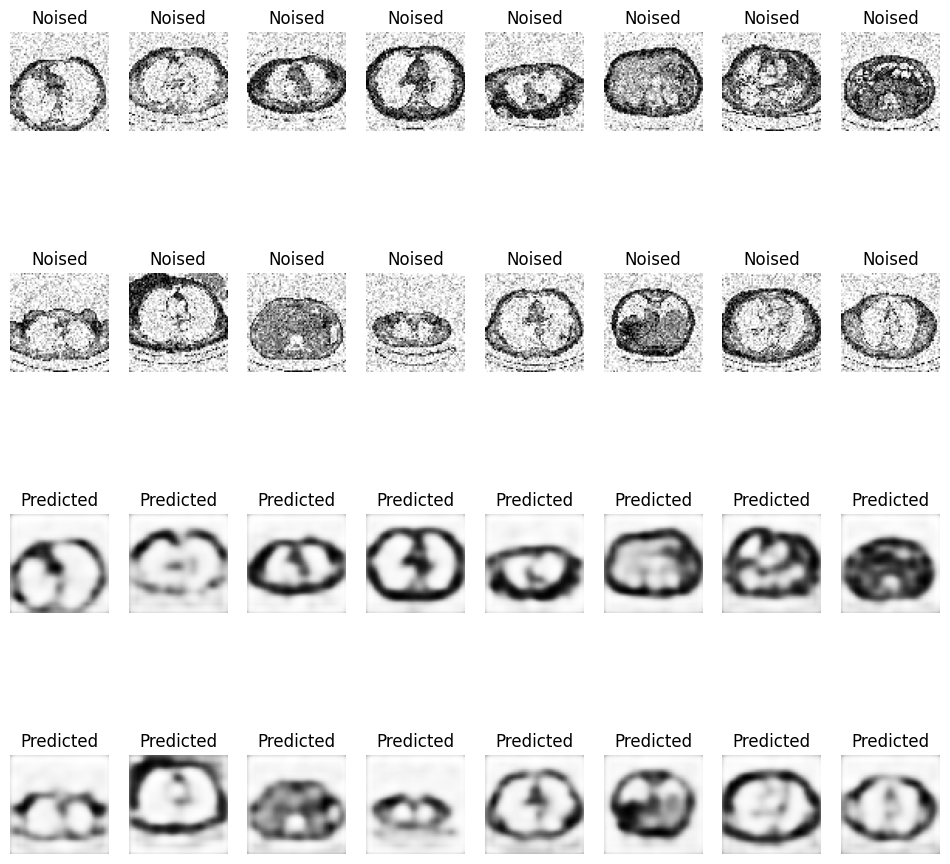

In [ ]:
plot_predictions(noise_test, predicted)

In [ ]:
import numpy as np
from skimage.metrics import peak_signal_noise_ratio

# Calculate PSNR for each pair of clean and denoised images and take the absolute value
psnr_values = [abs(peak_signal_noise_ratio(clean_img, denoised_img, data_range=denoised_img.max() - denoised_img.min())) for clean_img, denoised_img in zip(normal_test, predicted)]

# Calculate the average PSNR
average_psnr = np.mean(psnr_values)

# Print the average PSNR
print("Average PSNR:", average_psnr)


Average PSNR: 12.589906306170633


**PSNR (Peak Signal-to-Noise Ratio)** measures the quality of a denoised image by comparing it to the original clean image. A higher PSNR indicates better image quality (less difference from the original), while a lower PSNR suggests more distortion.

In [17]:
from keras.models import Sequential, Model
from keras.layers import Dense, Conv2D, MaxPooling2D,MaxPool2D ,UpSampling2D, Flatten, Input
from keras.optimizers import SGD, Adam, Adadelta, Adagrad
from keras import backend as K

def autoencoder():

    input_img = Input(shape=(64,64,1), name='image_input')

    #enoder
    x = Conv2D(128, (3,3), activation='relu', padding='same', name='Conv1')(input_img)
    x = MaxPooling2D((2,2), padding='same', name='pool1')(x)
    x = Conv2D(128, (3,3), activation='relu', padding='same', name='Conv2')(x)
    x = MaxPooling2D((2,2), padding='same', name='pool2')(x)   #32

    #decoder
    x = Conv2D(128, (3,3), activation='relu', padding='same', name='Conv3')(x)
    x = UpSampling2D((2,2), name='upsample1')(x)
    x = Conv2D(128, (3,3), activation='relu', padding='same', name='Conv4')(x)
    x = UpSampling2D((2,2), name='upsample2')(x)
    x = Conv2D(1, (3,3), activation='sigmoid', padding='same', name='Conv5')(x)

    #model
    autoencoder = Model(inputs=input_img, outputs=x)

    return autoencoder

In [18]:
autoencoder2= autoencoder()
autoencoder2.compile(optimizer='adam', loss='mean_squared_error')

In [ ]:
autoencoder2.fit(noise_train,
                 normal_train, epochs=150, batch_size=16, shuffle=True, validation_data=(noise_test, normal_test))

Epoch 1/150
5/5 ━━━━━━━━━━━━━━━━━━━━ 11s 2s/step - loss: 0.1196 - val_loss: 0.0869
Epoch 2/150
5/5 ━━━━━━━━━━━━━━━━━━━━ 12s 2s/step - loss: 0.0892 - val_loss: 0.0823
Epoch 3/150
5/5 ━━━━━━━━━━━━━━━━━━━━ 18s 2s/step - loss: 0.0772 - val_loss: 0.0720
Epoch 4/150
5/5 ━━━━━━━━━━━━━━━━━━━━ 8s 1s/step - loss: 0.0668 - val_loss: 0.0523
Epoch 5/150
5/5 ━━━━━━━━━━━━━━━━━━━━ 14s 2s/step - loss: 0.0496 - val_loss: 0.0449
Epoch 6/150
5/5 ━━━━━━━━━━━━━━━━━━━━ 8s 1s/step - loss: 0.0437 - val_loss: 0.0407
Epoch 7/150
5/5 ━━━━━━━━━━━━━━━━━━━━ 8s 1s/step - loss: 0.0396 - val_loss: 0.0386
Epoch 8/150
5/5 ━━━━━━━━━━━━━━━━━━━━ 10s 1s/step - loss: 0.0376 - val_loss: 0.0352
Epoch 9/150
5/5 ━━━━━━━━━━━━━━━━━━━━ 12s 1s/step - loss: 0.0343 - val_loss: 0.0332
Epoch 10/150
5/5 ━━━━━━━━━━━━━━━━━━━━ 11s 2s/step - loss: 0.0323 - val_loss: 0.0319
Epoch 11/150
5/5 ━━━━━━━━━━━━━━━━━━━━ 8s 1s/step - loss: 0.0315 - val_loss: 0.0316
Epoch 12/150
5/5 ━━━━━━━━━━━━━━━━━━━━ 10s 1s/step - loss: 0.0316 - val_loss: 0.0314
Epoch

In [ ]:
autoencoder2.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ image_input (InputLayer)             │ (None, 64, 64, 1)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ Conv1 (Conv2D)                       │ (None, 64, 64, 128)         │           1,280 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ pool1 (MaxPooling2D)                 │ (None, 32, 32, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ Conv2 (Conv2D)                       │ (None, 32, 32, 128)         │         147,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ pool2 (MaxPooling2D)                 │ (None, 16, 16, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ Conv3 (Conv2D)                       │ (None, 16, 16, 128)         │         147,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ upsample1 (UpSampling2D)             │ (None, 32, 32, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ Conv4 (Conv2D)                       │ (None, 32, 32, 128)         │         147,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ upsample2 (UpSampling2D)             │ (None, 64, 64, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ Conv5 (Conv2D)                       │ (None, 64, 64, 1)           │           1,153 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 445,185 (1.70 MB)

 Trainable params: 445,185 (1.70 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
predicted = autoencoder2.predict(noise_test)

1/1 [==============================] - 0s 123ms/step


In [ ]:
evaluation = autoencoder2.evaluate(noise_test, normal_test)
evaluation

1/1 [==============================] - 0s 36ms/step - loss: 0.0744


0.07443829625844955

In [ ]:
from sklearn.metrics import mean_squared_error
# Calculate Mean Squared Error (MSE)
actual_values_flat = normal_test.flatten()
predicted_values_flat = predicted.flatten()

mse = mean_squared_error(actual_values_flat, predicted_values_flat)

print("Mean Squared Error:", mse)

Mean Squared Error: 0.07443829


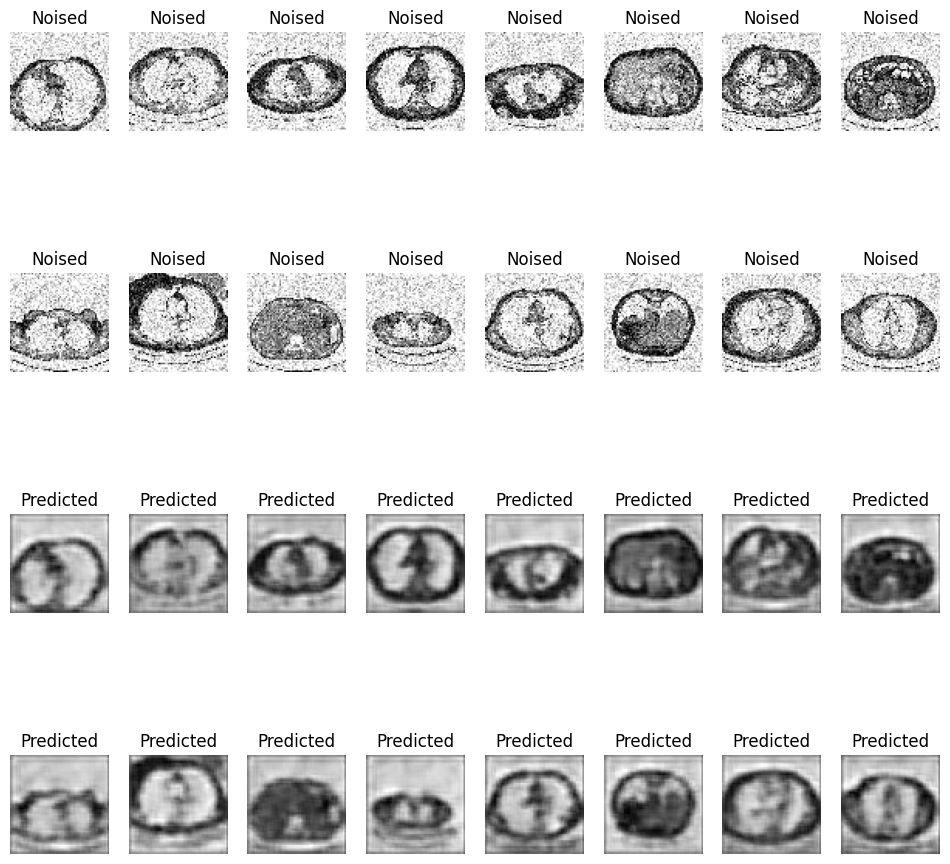

In [ ]:
plot_predictions(noise_test, predicted)

In [ ]:
import numpy as np
from skimage.metrics import peak_signal_noise_ratio

# Assuming clean_images and denoised_images are numpy arrays containing the clean and denoised grayscale images respectively

# Calculate PSNR for each pair of clean and denoised images and take the absolute value
psnr_values = [abs(peak_signal_noise_ratio(clean_img, denoised_img, data_range=denoised_img.max() - denoised_img.min())) for clean_img, denoised_img in zip(normal_test, predicted)]

# Calculate the average PSNR
average_psnr = np.mean(psnr_values)

# Print the average PSNR
print("Average PSNR:", average_psnr)


Average PSNR: 0.8276085807951448
